# Week 8 · Day 4 (companion) — The Same Network in TensorFlow / Keras

PyTorch is our main framework — but out in the world you'll meet **TensorFlow** (usually through its friendly front-end, **Keras**) just as often. Tutorials, Kaggle notebooks, company codebases: half are PyTorch, half are TensorFlow. You should be able to *read* both.

Good news: it's the **same network, the same four moves, the same XOR.** Only the words change. This short notebook shows the exact `2 → 4 → 1` network you built by hand and in PyTorch, now in Keras — so you can recognize the pattern anywhere.

**The plan:**
1. Same XOR data.
2. Define the network — Keras style (even shorter).
3. Train — Keras hides the loop, but the four moves are still in there.
4. Same 100%, same curved boundary.

In [1]:
# install if needed (Colab already has it)
# !pip install tensorflow

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.1


---
## 1. Same XOR data

Keras is happy with plain NumPy arrays — no special tensor type needed on our side. Same four points as every other version this week.

In [2]:
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([[0],[1],[1],[0]], dtype=float)

print("inputs X:\n", X)
print("targets y:", y.ravel())

inputs X:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
targets y: [0. 1. 1. 0.]


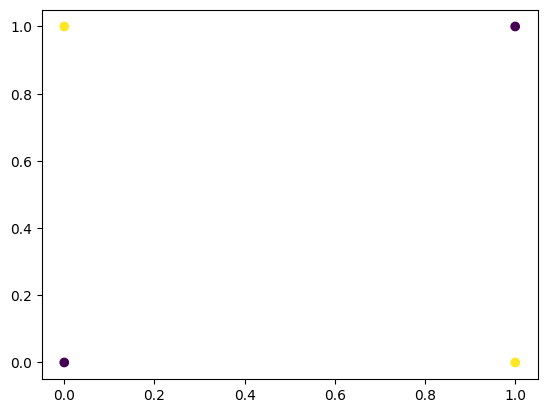

In [20]:
plt.scatter(X[:, 0], X[:, 1], c=y[:, 0])

---
## 2. Define the network

Compare this to PyTorch. In PyTorch you wrote a class (or `nn.Sequential`). In Keras it's `keras.Sequential` — almost identical, just different names:

| Your hand-built | PyTorch | Keras |
|---|---|---|
| `X @ W1 + b1` | `nn.Linear(2, 4)` | `Dense(4)` (after `Input(shape=(2,))`) |
| `sigmoid()` | `nn.Sigmoid()` | `activation="sigmoid"` |
| `a1 @ W2 + b2` | `nn.Linear(4, 1)` | `Dense(1)` |

Keras calls a fully-connected layer **`Dense`** instead of `Linear`, and lets you fold the activation *into* the layer. Same `2 → 4 → 1` network.

In [3]:
tf.random.set_seed(42)

model = keras.Sequential([
    keras.layers.Input(shape=(2,)),                    # tells Keras: 2 inputs
    keras.layers.Dense(4, activation="sigmoid"),       # hidden: 2 -> 4
    keras.layers.Dense(1, activation="sigmoid")        # output: 4 -> 1
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

### Compile — pick the loss and optimizer

In PyTorch you created `loss_fn` and `optimizer` as separate objects. Keras bundles that into one `compile` call — but it's the **same two choices**:

- `loss="mse"` — mean squared error, your `np.mean((pred - y)**2)`
- `optimizer=SGD(0.5)` — the same `W -= lr * dW` update, lr = 0.5

In [4]:
model.compile(
    loss="mse",
    optimizer=keras.optimizers.SGD(learning_rate=0.5),
    metrics=["accuracy"]
)
print("compiled — loss + optimizer chosen, same as PyTorch")

compiled — loss + optimizer chosen, same as PyTorch


---
## 3. Train

Here's the biggest difference. In PyTorch **you wrote the loop** — forward, loss, backward, update, 5000 times. Keras **writes the loop for you**: one call to `.fit()`.

But don't be fooled — the four moves are still happening inside `.fit()`, once per epoch. Keras just hides them. (This is why we built it by hand first: so you know what `.fit()` is really doing.)

In [5]:
history = model.fit(X, y, epochs=5000, verbose=0)   # verbose=0 keeps it quiet

print(type(history))
final_loss = history.history["loss"][-1]
print(f"final loss: {final_loss:.4f}")

<class 'keras.src.callbacks.history.History'>
final loss: 0.0015


In [10]:
len(history.history['accuracy'])

5000

In [11]:
history.history['loss']

[0.27306944131851196,
 0.2687830328941345,
 0.2651512026786804,
 0.26211127638816833,
 0.25959306955337524,
 0.2575252652168274,
 0.25583940744400024,
 0.25447314977645874,
 0.2533710300922394,
 0.2524852454662323,
 0.2517753839492798,
 0.25120753049850464,
 0.25075405836105347,
 0.2503920793533325,
 0.25010326504707336,
 0.24987274408340454,
 0.24968858063220978,
 0.2495412677526474,
 0.24942314624786377,
 0.24932818114757538,
 0.2492516040802002,
 0.24918954074382782,
 0.2491389364004135,
 0.24909742176532745,
 0.24906310439109802,
 0.24903444945812225,
 0.24901029467582703,
 0.24898968636989594,
 0.2489718496799469,
 0.24895623326301575,
 0.2489423304796219,
 0.24892979860305786,
 0.2489183247089386,
 0.24890770018100739,
 0.2488977015018463,
 0.24888823926448822,
 0.24887916445732117,
 0.248870387673378,
 0.24886184930801392,
 0.24885348975658417,
 0.24884524941444397,
 0.24883709847927094,
 0.24882905185222626,
 0.24882102012634277,
 0.24881300330162048,
 0.2488050013780594,
 0.24

### Did it solve XOR?

In [12]:
preds = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step


In [13]:
(preds>0.5).astype(int)

array([[0],
       [1],
       [1],
       [0]])

In [14]:
preds = model.predict(X, verbose=0)
predictions = (preds > 0.5).astype(int)

print("input     prediction   target")
for i in range(4):
    print(f"{X[i].astype(int)}        {predictions[i][0]}            {int(y[i][0])}")

accuracy = np.mean(predictions == y)
print(f"\naccuracy: {accuracy:.0%}")

input     prediction   target
[0 0]        0            0
[0 1]        1            1
[1 0]        1            1
[1 1]        0            0

accuracy: 100%


**100% — same result, third way of writing it.** Hand-built NumPy, PyTorch, Keras: three notebooks, one network, one answer.

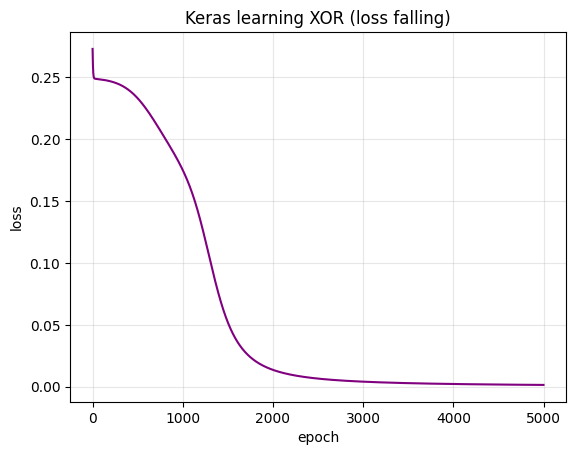

In [ ]:
plt.plot(history.history["loss"], color="purple")
plt.xlabel("epoch"); 
plt.ylabel("loss")
plt.title("Keras learning XOR (loss falling)")
plt.grid(alpha=0.3)
plt.show()

---
## 4. The curved boundary

Same payoff one more time — the curved decision boundary that only a multi-layer network can draw.

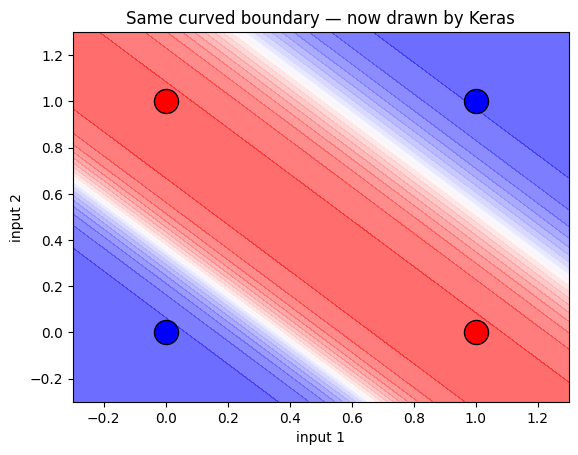

In [ ]:
xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 200), np.linspace(-0.3, 1.3, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_pred = model.predict(grid, verbose=0).reshape(xx.shape)

plt.contourf(xx, yy, grid_pred, levels=20, cmap="bwr", alpha=0.6)
for i in range(4):
    color = "red" if y[i] > 0.5 else "blue"
    plt.scatter(X[i,0], X[i,1], c=color, s=300, edgecolor="k", zorder=3)
plt.title("Same curved boundary — now drawn by Keras")
plt.xlabel("input 1"); plt.ylabel("input 2")
plt.show()

---
## PyTorch vs TensorFlow/Keras — the cheat sheet

You now know both. They map almost word-for-word:

| Step | PyTorch | Keras |
|---|---|---|
| Fully-connected layer | `nn.Linear(2, 4)` | `Dense(4)` (+ `Input(shape=(2,))`) |
| Build the model | `nn.Sequential(...)` or a class | `keras.Sequential([...])` |
| Pick loss + optimizer | `nn.MSELoss()`, `optim.SGD(...)` | `model.compile(loss=..., optimizer=...)` |
| Train | **you write the loop** | `model.fit(X, y, epochs=...)` |
| Predict | `model(X)` | `model.predict(X)` |

**The trade-off, in one line:** PyTorch makes you write the training loop, which means you *see* every step (great for learning and for research). Keras writes the loop for you, which means less code (great for standard tasks). Neither is doing anything you haven't already done by hand.

**Why we use PyTorch as our main framework:** because seeing the loop keeps the four moves visible while you're still learning — and it's what most modern deep-learning and AI research is written in today. But now, when you hit a TensorFlow notebook in the wild, you'll read it just fine.

---
## Summary

- The **same `2 → 4 → 1` network** solves XOR in Keras, exactly as it did by hand and in PyTorch.
- Keras names: `Dense` (= `Linear`), `compile` (= choosing loss + optimizer), `fit` (= the training loop, written for you).
- `.fit()` hides the four moves — but forward → loss → backward → update is still happening inside, once per epoch. You know this because you built it by hand.
- **You can now read both frameworks.** That's a real, practical skill — most code you meet will be one or the other.

> **PyTorch shows you the loop. Keras writes it for you. Same network, same math, same answer.**

Back to PyTorch tomorrow — our main tool for the rest of the course — now with the confidence that you understand what any framework is doing underneath.